# Prediccion de Enfermedad Renal Cronica (ERC) mediante Machine Learning
## Clasificacion Binaria Supervisada | Dataset NHANES 2021-2023

**Pregunta:** Es posible predecir la presencia de ERC a partir de variables clinicas, demograficas y de laboratorio mediante modelos de aprendizaje automatico supervisado con clasificacion binaria?

**Target:** `ckd_present` (0/1) | **Metrica:** AUC-ROC | **Dataset:** 11,933 registros

---
## FASE 0: Librerias

In [5]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", 35)
print("Librerias OK")

Librerias OK


---
## FASE 1: Carga y exploracion inicial

In [6]:
df = pd.read_csv("../data/CKD_NHANES_2021_2023.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (11933, 29)


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosphorus       

In [8]:
df.describe().round(2)

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.0,11933.00,7794.00,9892.00,8471.00,8754.00,8499.00,7517.00,7517.00,6326.00,6326.00,6366.00,6322.00,6325.00,6362.00,6329.00,8154.00,8153.00,8153.00,11740.00,1081.00,2281.00,8135.00,3243.00,6326.00,11933.00
mean,136344.0,38.32,3.80,2.71,27.25,70.55,159.66,119.29,72.75,0.87,14.66,4.10,3.61,24.45,9.43,5.13,133.26,35.57,33.36,1.93,1.68,1.63,1.61,2.34,96.60,0.70
std,3444.9,25.60,1.15,1.67,8.14,30.39,19.86,18.56,11.90,0.39,5.75,0.36,0.57,2.41,0.38,1.41,90.68,175.58,251.09,0.36,0.47,0.64,0.56,0.90,24.63,0.46
min,130378.0,0.00,1.00,0.00,11.10,2.70,79.10,61.00,33.00,0.33,4.00,2.20,1.60,15.00,7.50,1.10,4.00,0.21,0.08,1.00,1.00,1.00,1.00,1.00,3.51,0.00
25%,133361.0,13.00,3.00,1.18,21.60,54.20,154.40,106.00,64.00,0.70,11.00,3.90,3.20,23.00,9.20,4.10,65.00,5.77,5.42,2.00,1.00,1.00,1.00,1.00,80.50,0.00
50%,136344.0,37.00,4.00,2.50,26.40,71.70,163.60,117.00,72.00,0.83,14.00,4.10,3.60,24.00,9.40,5.00,117.00,9.62,8.27,2.00,2.00,2.00,2.00,3.00,97.03,1.00
75%,139327.0,62.00,5.00,4.50,31.70,89.10,172.10,130.00,80.00,0.98,17.00,4.30,3.90,26.00,9.70,6.00,181.00,17.83,15.33,2.00,2.00,2.00,2.00,3.00,112.66,1.00
max,142310.0,80.00,9.00,5.00,74.80,248.20,200.70,232.00,142.00,15.17,74.00,5.50,7.00,37.00,11.70,13.20,873.00,7942.47,14708.28,9.00,2.00,9.00,9.00,3.00,178.43,1.00


In [9]:
# Nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)
pd.DataFrame({"Nulos": nulos, "%": nulos_pct})[nulos > 0]

,Nulos,%
insulin_use,10852,90.9
diabetes_pills,9652,80.9
current_smoker,8690,72.8
phosphorus,5611,47.0
bicarbonate,5608,47.0
blood_urea_nitrogen,5607,47.0
serum_creatinine,5607,47.0
egfr,5607,47.0
uric_acid,5604,47.0
calcium,5571,46.7


ckd_present
1    8341
0    3592
Name: count, dtype: int64

CKD: 69.9% | No CKD: 30.1%


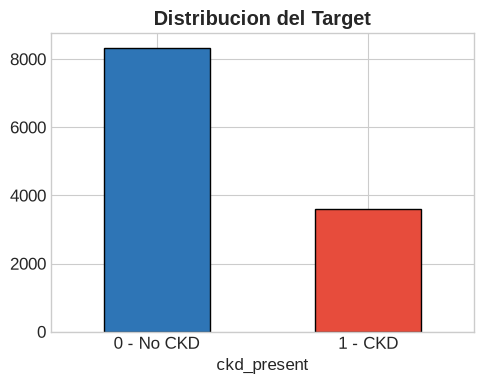

In [10]:
# Target
print(df["ckd_present"].value_counts())
print(
    f"\nCKD: {df['ckd_present'].mean() * 100:.1f}% | No CKD: {(1 - df['ckd_present'].mean()) * 100:.1f}%"
)

fig, ax = plt.subplots(figsize=(5, 4))
df["ckd_present"].value_counts().plot(
    kind="bar", color=["#2E75B6", "#E74C3C"], edgecolor="black", ax=ax
)
ax.set_title("Distribucion del Target", fontweight="bold")
ax.set_xticklabels(["0 - No CKD", "1 - CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
## FASE 2: Eliminacion de variables (fuga + redundancia)

| Variable | Razon | Tipo |
|---|---|---|
| `egfr` | Define el target (eGFR<60 = CKD) | Fuga directa |
| `ckd_stage` | Derivada de eGFR + ACR | Fuga directa |
| `serum_creatinine` | Insumo de CKD-EPI: eGFR=f(creatinina,edad,sexo) | Fuga proxy |
| `participant_id` | ID sin valor predictivo | N/A |
| `weight_kg`, `height_cm` | Redundantes con BMI | Redundancia |
| `insulin_use` | 91% nulos | Nulos excesivos |
| `diabetes_pills` | 81% nulos | Nulos excesivos |
| `current_smoker` | 73% nulos | Nulos excesivos |

In [11]:
vars_eliminar = [
    "participant_id",
    "egfr",
    "ckd_stage",
    "serum_creatinine",
    "weight_kg",
    "height_cm",
    "insulin_use",
    "diabetes_pills",
    "current_smoker",
]
print(f"Antes: {df.shape[1]} columnas")
df_clean = df.drop(columns=vars_eliminar)
print(f"Despues: {df_clean.shape[1]} columnas")
print(f"Conservadas: {list(df_clean.columns)}")

Antes: 29 columnas
Despues: 20 columnas
Conservadas: ['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked', 'ckd_present']


---
## FASE 3: Tratamiento de datos

### 3.1 Recodificacion

In [12]:
# diabetes_diagnosed: 1=si, 2=no, 3=borderline, 9=no sabe
print("Original:", df_clean["diabetes_diagnosed"].value_counts().to_dict())
df_clean["diabetes_diagnosed"] = df_clean["diabetes_diagnosed"].replace(
    {1: 1, 2: 0, 3: 0, 9: np.nan}
)
print(
    "Recodificado:", df_clean["diabetes_diagnosed"].value_counts(dropna=False).to_dict()
)

Original: {2.0: 10371, 1.0: 1081, 3.0: 284, 9.0: 4}
Recodificado: {0.0: 10655, 1.0: 1081, nan: 197}


### 3.2 Filtrado de registros sin laboratorios

In [13]:
# Los ~47% de nulos en labs son los mismos pacientes sin examenes de sangre
# Guardar copia ANTES del filtrado para comparar despues
df_antes_filtro = df_clean.copy()

# Filtrar: conservar registros que tengan labs
df_labs = df_clean.dropna(subset=["blood_urea_nitrogen"])
print(
    f"Registros con labs: {len(df_labs)} de {len(df_clean)} ({len(df_labs) / len(df_clean) * 100:.1f}%)"
)
print(f"Target: {df_labs['ckd_present'].value_counts().to_dict()}")
print(f"CKD: {df_labs['ckd_present'].mean() * 100:.1f}%")

Registros con labs: 6326 de 11933 (53.0%)
Target: {0: 3590, 1: 2736}
CKD: 43.3%


In [14]:
# Nulos restantes
nulos_post = df_labs.isnull().sum().sort_values(ascending=False)
nulos_pct_post = (nulos_post / len(df_labs) * 100).round(1)
print("Nulos restantes:")
print(pd.DataFrame({"Nulos": nulos_post, "%": nulos_pct_post})[nulos_post > 0])

Nulos restantes:
                          Nulos     %
education_level             882  13.9
poverty_income_ratio        794  12.6
ever_smoked                 669  10.6
bp_diastolic                193   3.1
bp_systolic                 193   3.1
urine_albumin               124   2.0
albumin_creatinine_ratio    124   2.0
urine_creatinine            123   1.9
bmi                          81   1.3
phosphorus                   19   0.3
bicarbonate                   1   0.0
diabetes_diagnosed            1   0.0
calcium                       1   0.0


### 3.3 Transformacion logaritmica de variables sesgadas

In [15]:
# Guardar valores ANTES de transformar para el boxplot comparativo
acr_antes = df_labs["albumin_creatinine_ratio"].copy()
ualb_antes = df_labs["urine_albumin"].copy()

log_vars = ["albumin_creatinine_ratio", "urine_albumin"]
for var in log_vars:
    print(f"{var}:")
    print(f"  Skewness ANTES: {df_labs[var].skew():.2f}")
    df_labs[var] = np.log1p(df_labs[var])
    print(f"  Skewness DESPUES: {df_labs[var].skew():.2f}\n")

albumin_creatinine_ratio:
  Skewness ANTES: 32.18
  Skewness DESPUES: 1.53

urine_albumin:
  Skewness ANTES: 20.81
  Skewness DESPUES: 0.90



### 3.4 Comparacion ANTES vs DESPUES del tratamiento de datos

Boxplots lado a lado para ver el efecto de la transformacion logaritmica y la limpieza.

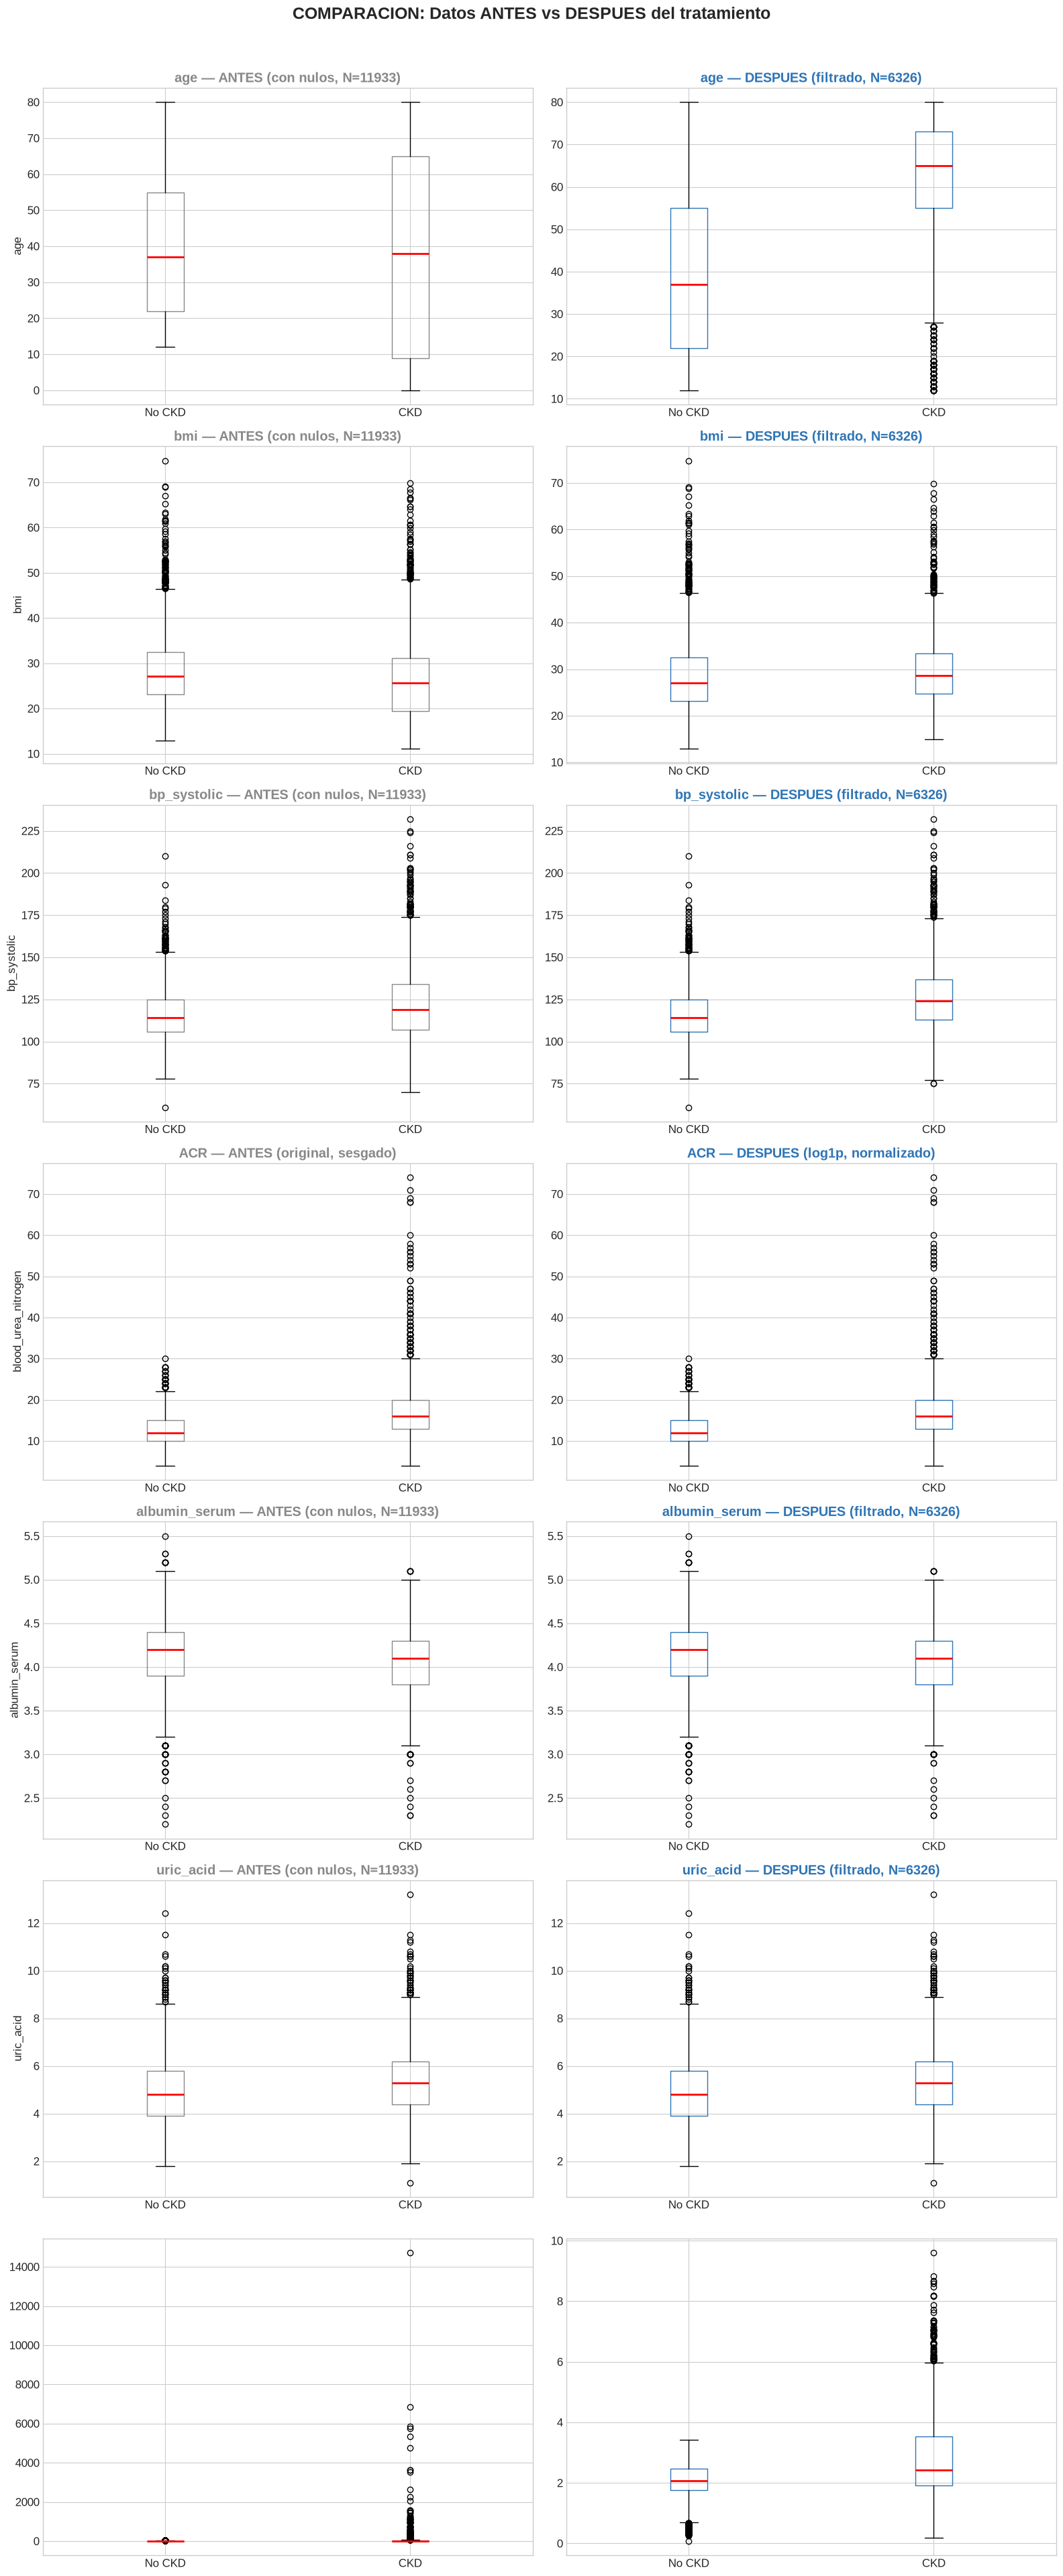

In [16]:
# ====================================================================
# BOXPLOTS COMPARATIVOS: ANTES vs DESPUES del tratamiento
# ====================================================================
compare_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
]

fig, axes = plt.subplots(7, 2, figsize=(16, 38))

# --- Variables normales: antes (df_antes_filtro) vs despues (df_labs) ---
for i, var in enumerate(compare_vars):
    row = i
    # ANTES
    data_antes_0 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 0, var
    ].dropna()
    data_antes_1 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 1, var
    ].dropna()
    axes[row][0].boxplot(
        [data_antes_0, data_antes_1],
        tick_labels=["No CKD", "CKD"],
        boxprops=dict(color="#888"),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[row][0].set_title(
        f"{var} — ANTES (con nulos, N={len(df_antes_filtro)})",
        fontweight="bold",
        color="#888",
    )
    axes[row][0].set_ylabel(var)

    # DESPUES
    data_desp_0 = df_labs.loc[df_labs["ckd_present"] == 0, var].dropna()
    data_desp_1 = df_labs.loc[df_labs["ckd_present"] == 1, var].dropna()
    axes[row][1].boxplot(
        [data_desp_0, data_desp_1],
        tick_labels=["No CKD", "CKD"],
        boxprops=dict(color="#2E75B6"),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[row][1].set_title(
        f"{var} — DESPUES (filtrado, N={len(df_labs)})",
        fontweight="bold",
        color="#2E75B6",
    )

    if i >= 5:
        break

# --- ACR: antes (original) vs despues (log) ---
row_acr = 6  # fila 6 (tras las 6 variables)
# ACR ANTES
d0 = acr_antes[df_labs["ckd_present"] == 0].dropna()
d1 = acr_antes[df_labs["ckd_present"] == 1].dropna()
axes[6][0].boxplot(
    [d0, d1],
    tick_labels=["No CKD", "CKD"],
    boxprops=dict(color="#888"),
    medianprops=dict(color="red", linewidth=2),
)
axes[3][0].set_title("ACR — ANTES (original, sesgado)", fontweight="bold", color="#888")

# ACR DESPUES (log)
d0l = df_labs.loc[df_labs["ckd_present"] == 0, "albumin_creatinine_ratio"].dropna()
d1l = df_labs.loc[df_labs["ckd_present"] == 1, "albumin_creatinine_ratio"].dropna()
axes[6][1].boxplot(
    [d0l, d1l],
    tick_labels=["No CKD", "CKD"],
    boxprops=dict(color="#2E75B6"),
    medianprops=dict(color="red", linewidth=2),
)
axes[3][1].set_title(
    "ACR — DESPUES (log1p, normalizado)", fontweight="bold", color="#2E75B6"
)

plt.suptitle(
    "COMPARACION: Datos ANTES vs DESPUES del tratamiento",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## FASE 4: EDA sobre datos tratados

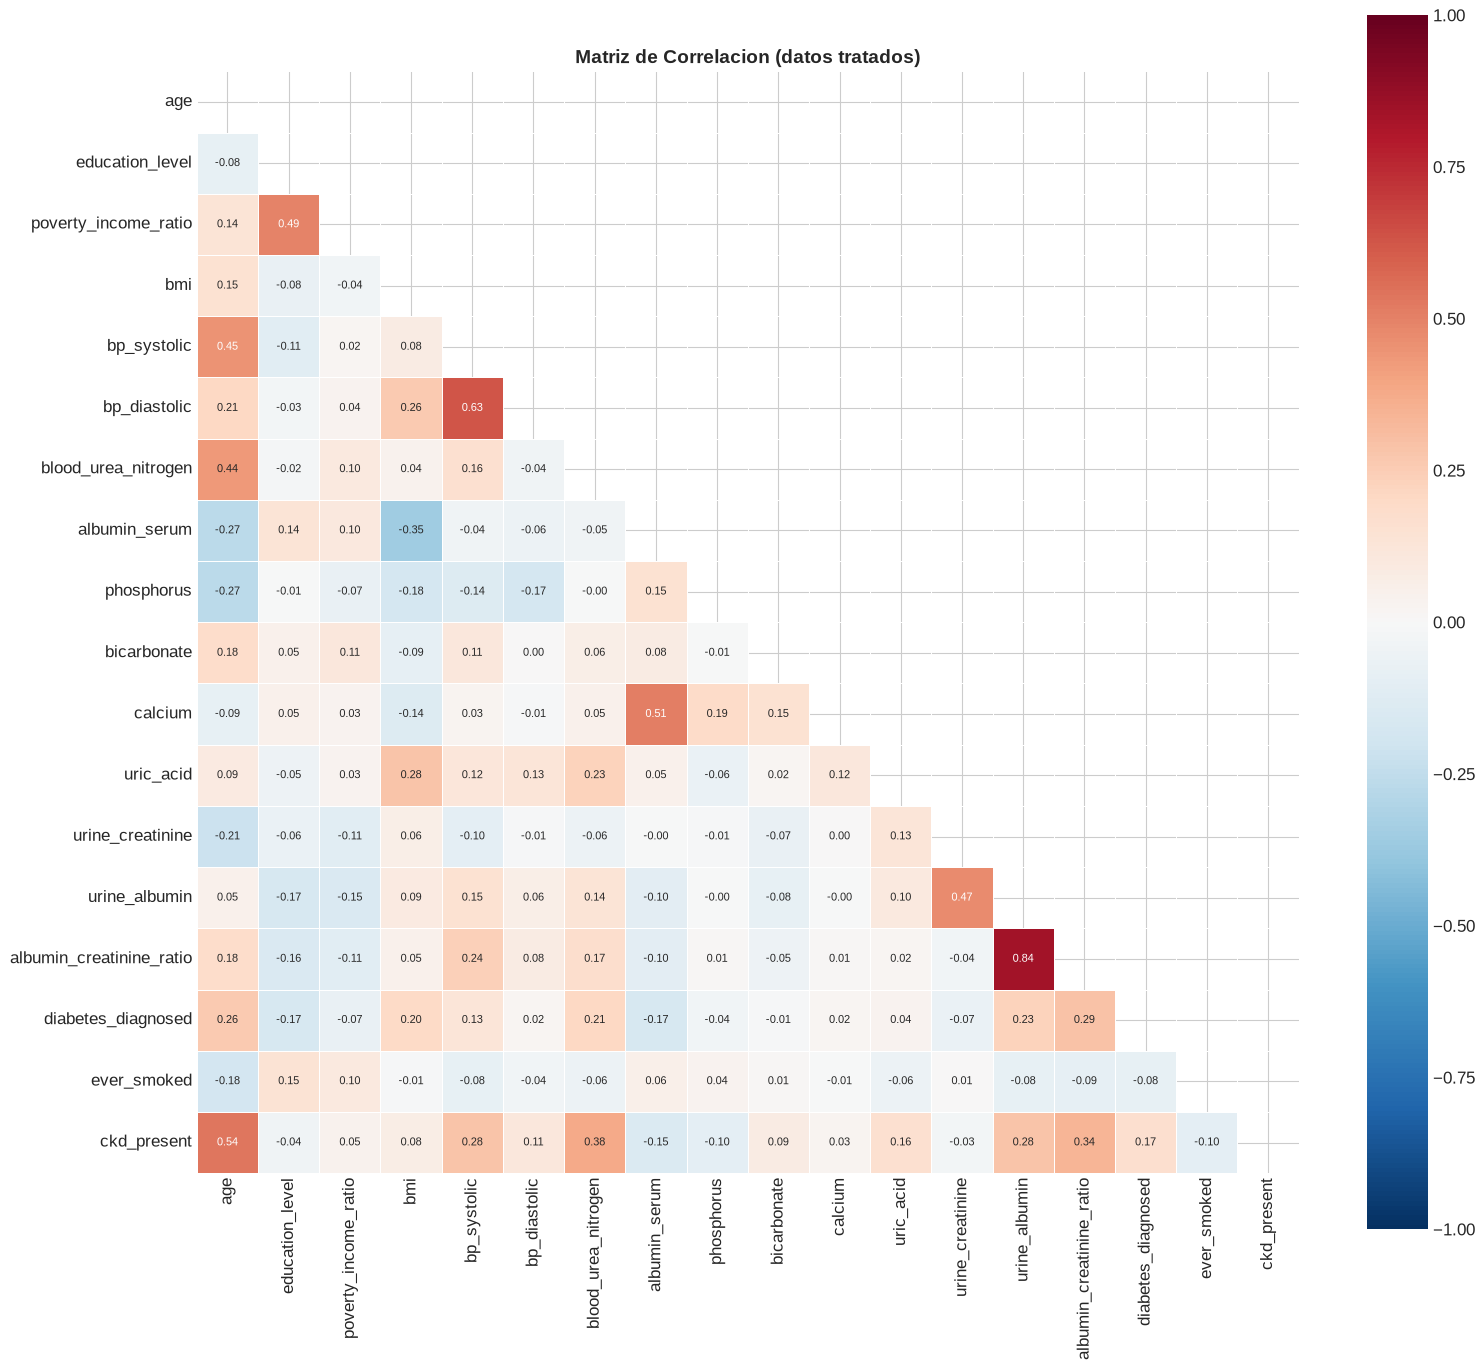

In [17]:
# Matriz de correlacion
num_data = df_labs.select_dtypes(include=[np.number])
corr = num_data.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},
)
plt.title("Matriz de Correlacion (datos tratados)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

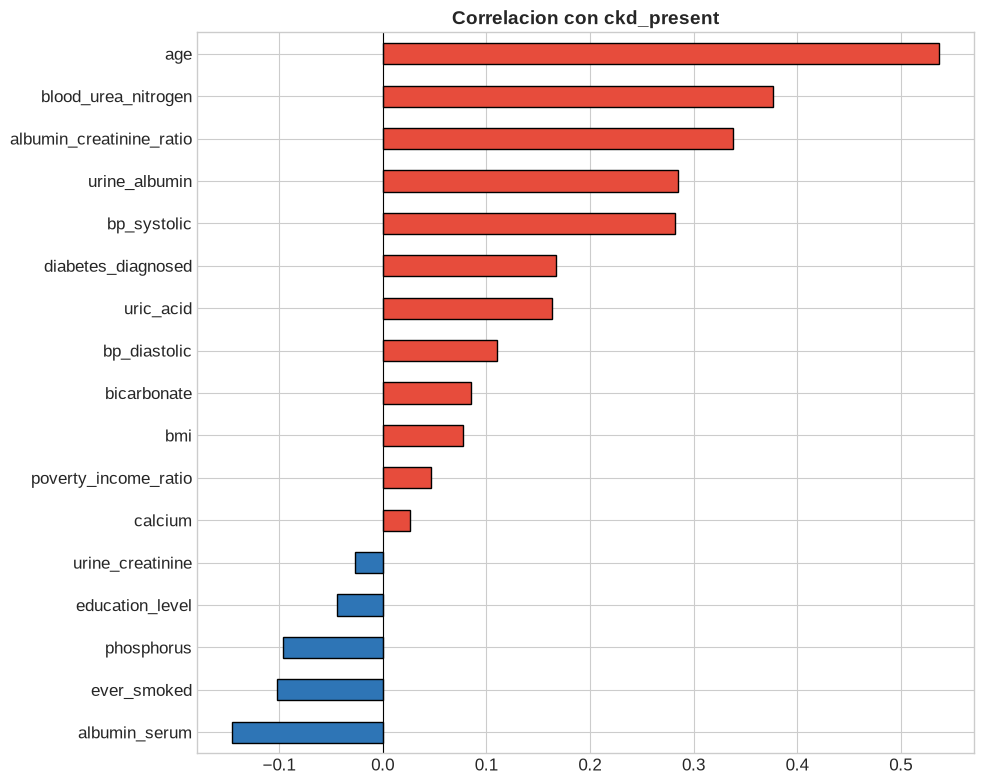

In [18]:
# Correlacion con target
corr_target = num_data.corr()["ckd_present"].drop("ckd_present").sort_values()
plt.figure(figsize=(10, 8))
colors = ["#E74C3C" if x > 0 else "#2E75B6" for x in corr_target.values]
corr_target.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Correlacion con ckd_present", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

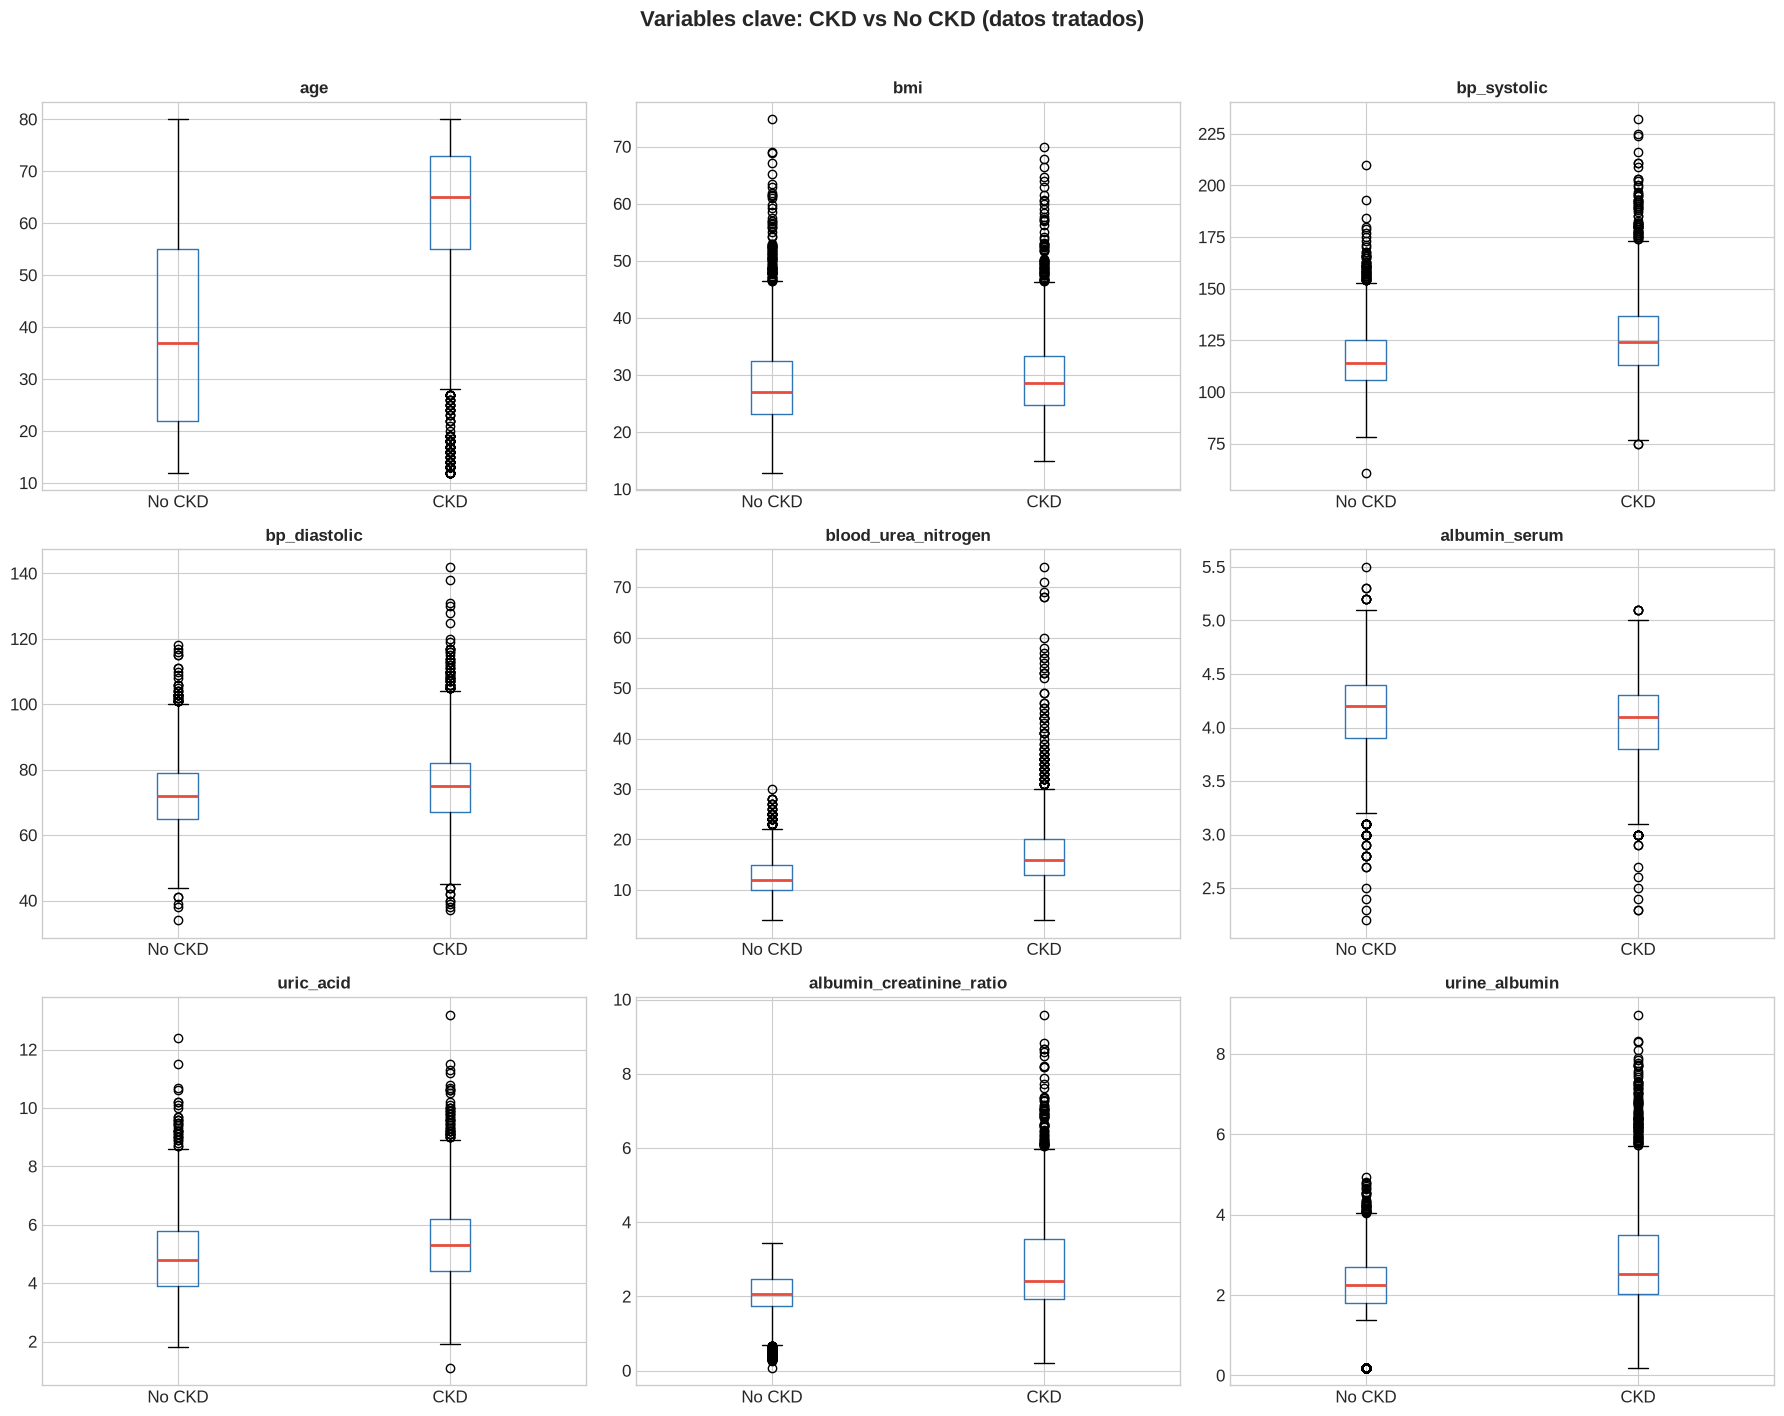

In [19]:
# Boxplots limpios finales
key_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "bp_diastolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
    "albumin_creatinine_ratio",
    "urine_albumin",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    ax = axes[i]
    d0 = df_labs.loc[df_labs["ckd_present"] == 0, col].dropna()
    d1 = df_labs.loc[df_labs["ckd_present"] == 1, col].dropna()
    ax.boxplot(
        [d0, d1],
        tick_labels=["No CKD", "CKD"],
        boxprops=dict(color="#2E75B6"),
        medianprops=dict(color="#E74C3C", linewidth=2),
    )
    ax.set_title(col, fontsize=12, fontweight="bold")
plt.suptitle(
    "Variables clave: CKD vs No CKD (datos tratados)",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## FASE 5: Preprocesamiento, Split y Balanceo

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

X = df_labs.drop(columns=["ckd_present"])
y = df_labs["ckd_present"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} ({y_train.mean() * 100:.1f}% CKD)")
print(f"Test:  {X_test.shape[0]} ({y_test.mean() * 100:.1f}% CKD)")

Train: 5060 (43.2% CKD)
Test:  1266 (43.3% CKD)


In [21]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
print(f"Numericas ({len(numeric_cols)}): {numeric_cols}")
print(f"Categoricas ({len(categorical_cols)}): {categorical_cols}")

Numericas (17): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked']
Categoricas (2): ['gender', 'ethnicity']


In [22]:
# Pipeline: KNNImputer + RobustScaler para numericas, OneHot para categoricas
numeric_pipeline = Pipeline(
    [("imputer", KNNImputer(n_neighbors=5)), ("scaler", RobustScaler())]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(
    categorical_cols
)
all_features = list(numeric_cols) + list(cat_names)

print(f"Features: {X_train_prep.shape[1]}")
print(
    f"Nulos train: {np.isnan(X_train_prep).sum()} | Nulos test: {np.isnan(X_test_prep).sum()}"
)

Features: 25
Nulos train: 0 | Nulos test: 0


ANTES:  No CKD=2872 | CKD=2188
DESPUES: No CKD=2872 | CKD=2872


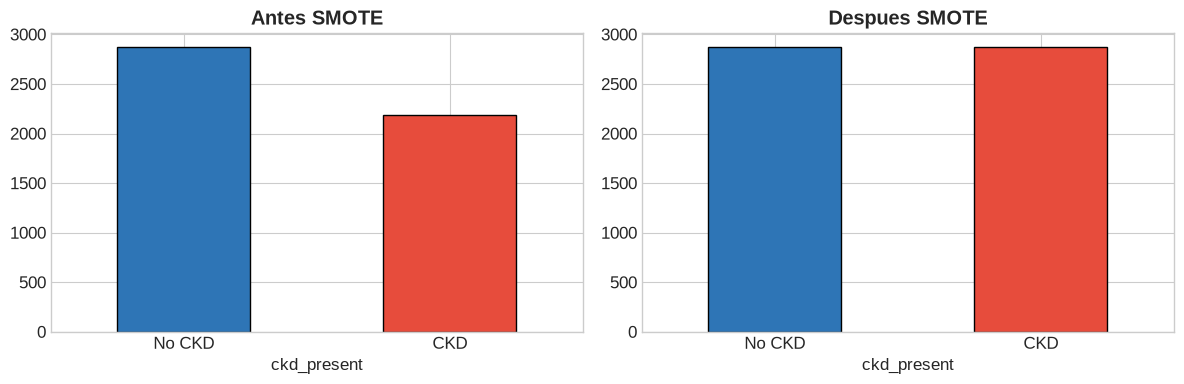

In [23]:
# SMOTE (solo en train)
from imblearn.over_sampling import SMOTE

print(f"ANTES:  No CKD={(y_train == 0).sum()} | CKD={(y_train == 1).sum()}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)
print(f"DESPUES: No CKD={(y_train_bal == 0).sum()} | CKD={(y_train_bal == 1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[0].set_title("Antes SMOTE", fontweight="bold")
axes[0].set_xticklabels(["No CKD", "CKD"], rotation=0)
pd.Series(y_train_bal).value_counts().plot(
    kind="bar", ax=axes[1], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[1].set_title("Despues SMOTE", fontweight="bold")
axes[1].set_xticklabels(["No CKD", "CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
## FASE 6: Entrenamiento de modelos base + Cross-Validation

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    auc = cross_val_score(
        model, X_train_bal, y_train_bal, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    f1 = cross_val_score(
        model, X_train_bal, y_train_bal, cv=cv, scoring="f1", n_jobs=-1
    )
    acc = cross_val_score(
        model, X_train_bal, y_train_bal, cv=cv, scoring="accuracy", n_jobs=-1
    )
    recall = cross_val_score(
        model, X_train_bal, y_train_bal, cv=cv, scoring="recall", n_jobs=-1
    )

    results[name] = {
        "AUC-ROC": f"{auc.mean():.4f} (+/- {auc.std():.4f})",
        "F1": f"{f1.mean():.4f} (+/- {f1.std():.4f})",
        "Accuracy": f"{acc.mean():.4f} (+/- {acc.std():.4f})",
        "Recall": f"{recall.mean():.4f} (+/- {recall.std():.4f})",
        "AUC_mean": auc.mean(),
    }
    print(f"  AUC-ROC:  {auc.mean():.4f} (+/- {auc.std():.4f})")
    print(f"  F1:       {f1.mean():.4f} (+/- {f1.std():.4f})")
    print(f"  Accuracy: {acc.mean():.4f} (+/- {acc.std():.4f})")
    print(f"  Recall:   {recall.mean():.4f} (+/- {recall.std():.4f})")

pd.DataFrame(results).T.drop(columns=["AUC_mean"])


Logistic Regression
  AUC-ROC:  0.8759 (+/- 0.0055)
  F1:       0.7918 (+/- 0.0084)
  Accuracy: 0.7906 (+/- 0.0080)
  Recall:   0.7967 (+/- 0.0122)

Random Forest
  AUC-ROC:  0.9279 (+/- 0.0053)
  F1:       0.8457 (+/- 0.0053)
  Accuracy: 0.8430 (+/- 0.0047)
  Recall:   0.8607 (+/- 0.0111)

XGBoost
  AUC-ROC:  0.9302 (+/- 0.0063)
  F1:       0.8448 (+/- 0.0123)
  Accuracy: 0.8444 (+/- 0.0126)
  Recall:   0.8468 (+/- 0.0147)


,AUC-ROC,F1,Accuracy,Recall
Logistic Regression,0.8759 (+/- 0.0055),0.7918 (+/- 0.0084),0.7906 (+/- 0.0080),0.7967 (+/- 0.0122)
Random Forest,0.9279 (+/- 0.0053),0.8457 (+/- 0.0053),0.8430 (+/- 0.0047),0.8607 (+/- 0.0111)
XGBoost,0.9302 (+/- 0.0063),0.8448 (+/- 0.0123),0.8444 (+/- 0.0126),0.8468 (+/- 0.0147)


---
## FASE 7: Optimizacion de hiperparametros (GridSearchCV)

Random Forest y XGBoost estan muy cerca (~0.93 AUC). Con GridSearch buscamos la mejor combinacion de hiperparametros para cada uno.

In [25]:
import time

from sklearn.model_selection import GridSearchCV

# =============================================
# GRID SEARCH - RANDOM FOREST
# =============================================
print("=" * 60)
print("GRID SEARCH: Random Forest")
print("=" * 60)

rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

t0 = time.time()
rf_grid.fit(X_train_bal, y_train_bal)
t_rf = time.time() - t0

print(f"\nTiempo: {t_rf:.1f}s")
print(f"Mejor AUC-ROC: {rf_grid.best_score_:.4f}")
print(f"Mejores parametros: {rf_grid.best_params_}")

GRID SEARCH: Random Forest
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/home/donpedromz/Documents/UAM/2026/Aprendizaje-Automatico/Proyecto-final/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/donpedromz/Documents/UAM/2026/Aprendizaje-Automatico/Proyecto-final/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/donpedromz/Documents/UAM/2026/Aprendizaje-Automatico/Proyecto-final/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propa


Tiempo: 92.8s
Mejor AUC-ROC: 0.9302
Mejores parametros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [27]:
# =============================================
# GRID SEARCH - XGBOOST
# =============================================
print("=" * 60)
print("GRID SEARCH: XGBoost")
print("=" * 60)

xgb_params = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1
    ),
    xgb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

t0 = time.time()
xgb_grid.fit(X_train_bal, y_train_bal)
t_xgb = time.time() - t0

print(f"\nTiempo: {t_xgb:.1f}s")
print(f"Mejor AUC-ROC: {xgb_grid.best_score_:.4f}")
print(f"Mejores parametros: {xgb_grid.best_params_}")

GRID SEARCH: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Tiempo: 51.2s
Mejor AUC-ROC: 0.9343
Mejores parametros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}


In [28]:
# =============================================
# COMPARACION: Base vs Optimizado
# =============================================
print("=" * 60)
print("COMPARACION: ANTES vs DESPUES de GridSearch")
print("=" * 60)
print("\nRandom Forest:")
print(f"  Base:       AUC = {results['Random Forest']['AUC_mean']:.4f}")
print(f"  Optimizado: AUC = {rf_grid.best_score_:.4f}")
print(
    f"  Mejora:     {(rf_grid.best_score_ - results['Random Forest']['AUC_mean']) * 100:+.2f}%"
)

print("\nXGBoost:")
print(f"  Base:       AUC = {results['XGBoost']['AUC_mean']:.4f}")
print(f"  Optimizado: AUC = {xgb_grid.best_score_:.4f}")
print(
    f"  Mejora:     {(xgb_grid.best_score_ - results['XGBoost']['AUC_mean']) * 100:+.2f}%"
)

# Elegir el mejor entre los dos optimizados
if rf_grid.best_score_ >= xgb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest (optimizado)"
    best_auc_cv = rf_grid.best_score_
else:
    best_model = xgb_grid.best_estimator_
    best_name = "XGBoost (optimizado)"
    best_auc_cv = xgb_grid.best_score_

print(f"\n>>> MEJOR MODELO FINAL: {best_name} (AUC CV = {best_auc_cv:.4f})")

COMPARACION: ANTES vs DESPUES de GridSearch

Random Forest:
  Base:       AUC = 0.9279
  Optimizado: AUC = 0.9302
  Mejora:     +0.23%

XGBoost:
  Base:       AUC = 0.9302
  Optimizado: AUC = 0.9343
  Mejora:     +0.41%

>>> MEJOR MODELO FINAL: XGBoost (optimizado) (AUC CV = 0.9343)


---
## FASE 8: Evaluacion final en Test Set

In [29]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Predecir en TEST
y_pred = best_model.predict(X_test_prep)
y_prob = best_model.predict_proba(X_test_prep)[:, 1]

print(f"Modelo: {best_name}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No CKD', 'CKD'])}")

Modelo: XGBoost (optimizado)
AUC-ROC: 0.9061
AUC-PR:  0.8944

              precision    recall  f1-score   support

      No CKD       0.83      0.86      0.84       718
         CKD       0.80      0.78      0.79       548

    accuracy                           0.82      1266
   macro avg       0.82      0.82      0.82      1266
weighted avg       0.82      0.82      0.82      1266



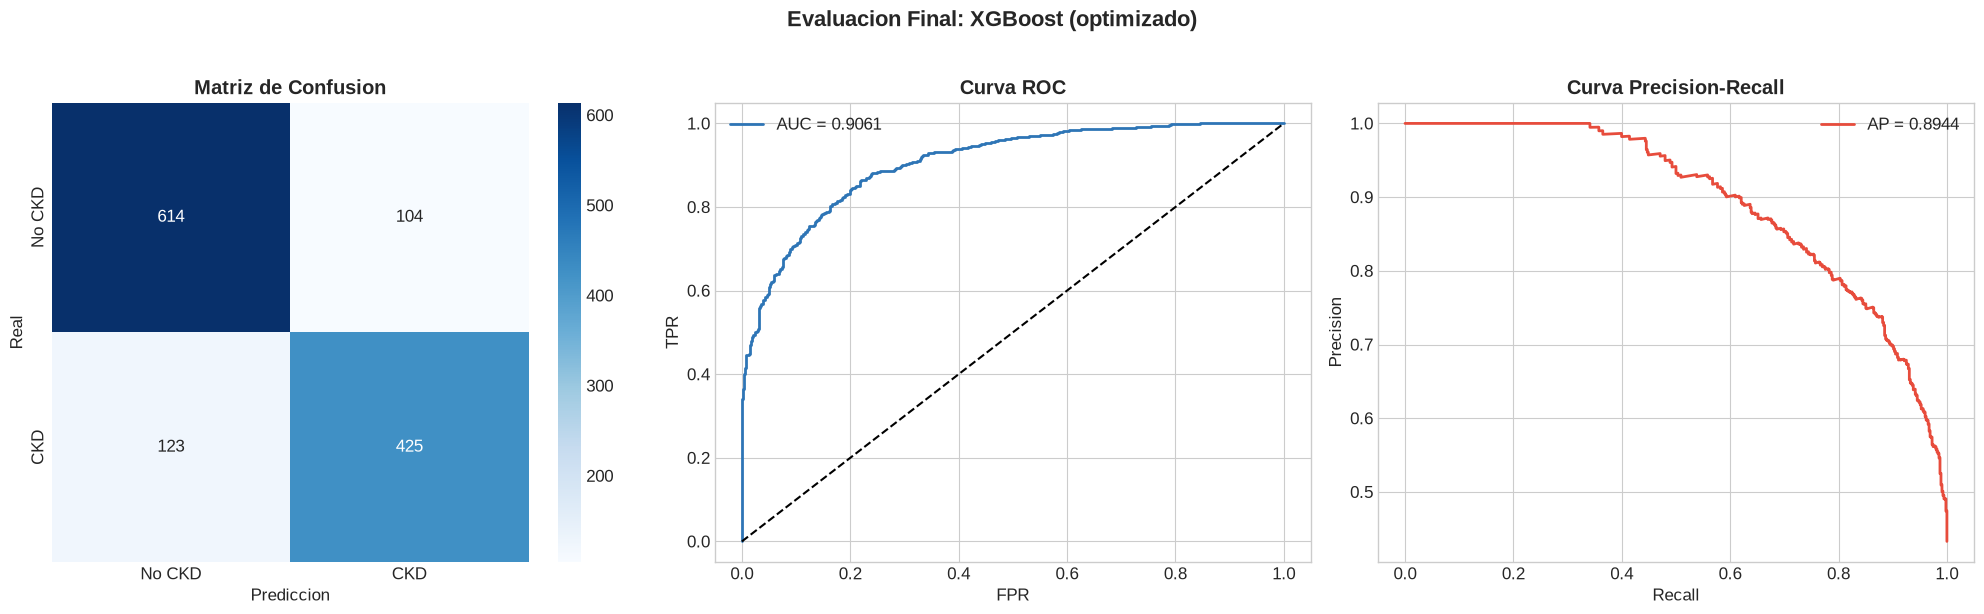

In [30]:
# Confusion matrix + ROC + PR
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No CKD", "CKD"],
    yticklabels=["No CKD", "CKD"],
)
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de Confusion", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(
    fpr,
    tpr,
    color="#2E75B6",
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}",
)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(
    rec,
    prec,
    color="#E74C3C",
    linewidth=2,
    label=f"AP = {average_precision_score(y_test, y_prob):.4f}",
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall", fontweight="bold")
axes[2].legend()

plt.suptitle(f"Evaluacion Final: {best_name}", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## FASE 9: Interpretabilidad con SHAP

In [31]:
import shap

# TreeExplainer para modelos basados en arboles
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_prep)

# Ajustar segun tipo
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
    base_val = explainer.expected_value[1]
else:
    shap_vals = shap_values
    base_val = explainer.expected_value

print(f"SHAP values: {shap_vals.shape}")

SHAP values: (1266, 25)


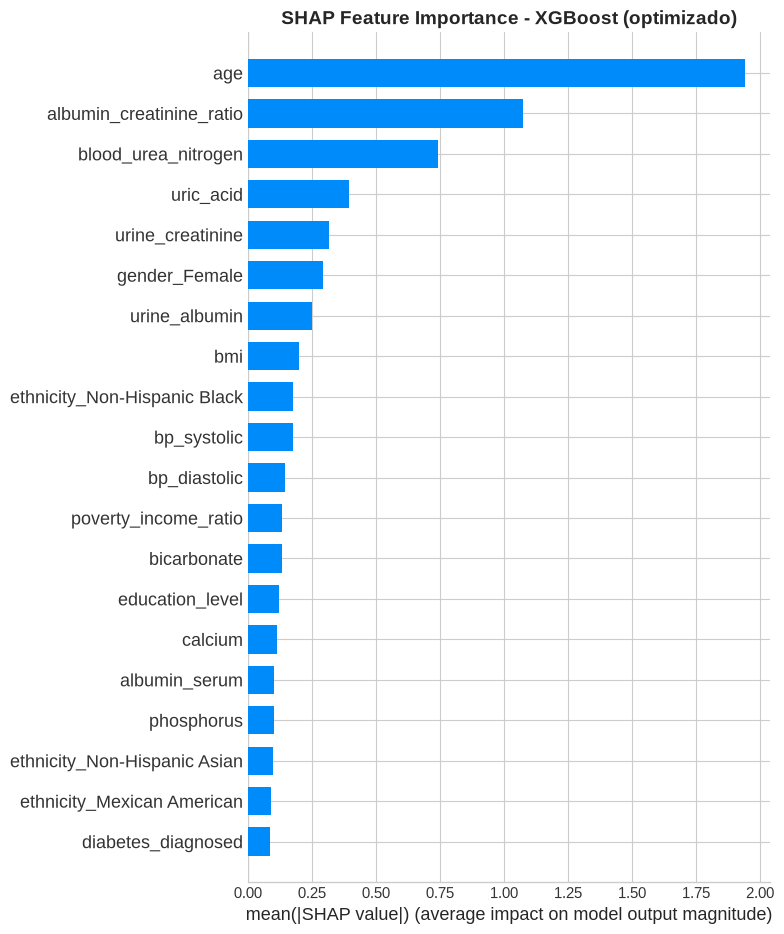

In [27]:
# Bar plot (importancia global)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_test_prep,
    feature_names=all_features,
    plot_type="bar",
    show=False,
    max_display=20,
)
plt.title(f"SHAP Feature Importance - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

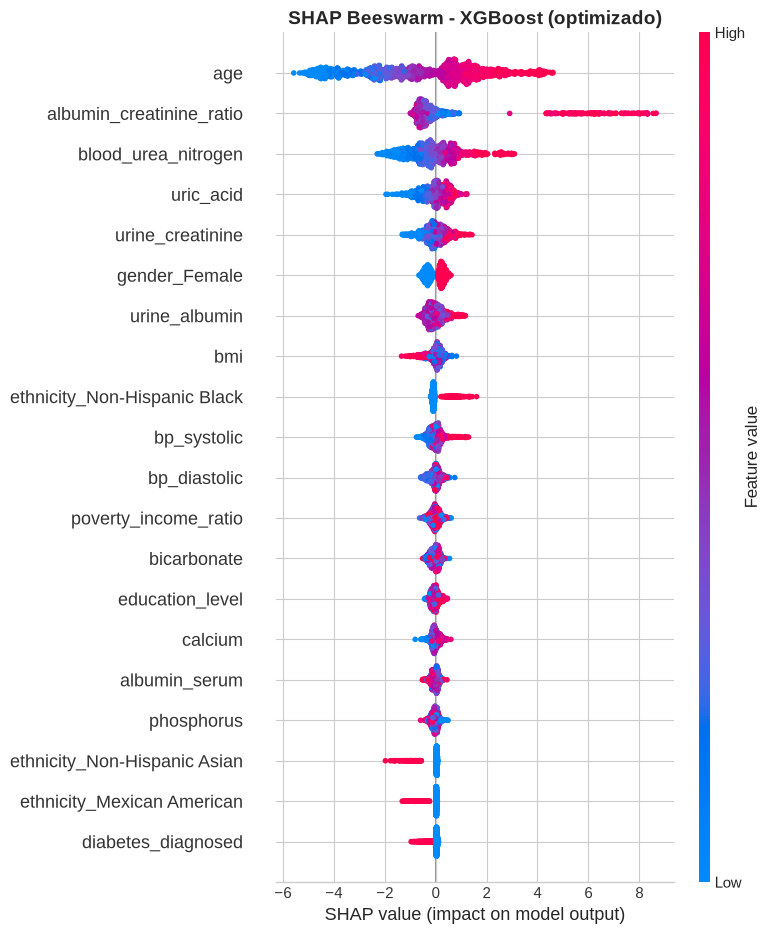

In [28]:
# Beeswarm plot (importancia + direccion)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_vals, X_test_prep, feature_names=all_features, show=False, max_display=20
)
plt.title(f"SHAP Beeswarm - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
# Top 10 features
shap_importance = pd.DataFrame(
    {"Feature": all_features, "Mean |SHAP|": np.abs(shap_vals).mean(axis=0)}
).sort_values("Mean |SHAP|", ascending=False)

print("Top 10 variables (SHAP):")
print("=" * 55)
for _, row in shap_importance.head(10).iterrows():
    bar = "█" * int(row["Mean |SHAP|"] / shap_importance["Mean |SHAP|"].max() * 25)
    print(f"  {row['Feature']:35s} {row['Mean |SHAP|']:.4f}  {bar}")

Top 10 variables (SHAP):
  age                                 1.9429  █████████████████████████
  albumin_creatinine_ratio            1.0745  █████████████
  blood_urea_nitrogen                 0.7439  █████████
  uric_acid                           0.3948  █████
  urine_creatinine                    0.3187  ████
  gender_Female                       0.2953  ███
  urine_albumin                       0.2495  ███
  bmi                                 0.2004  ██
  ethnicity_Non-Hispanic Black        0.1752  ██
  bp_systolic                         0.1743  ██


Paciente con CKD | Prob: 0.0174 | Real: CKD=1


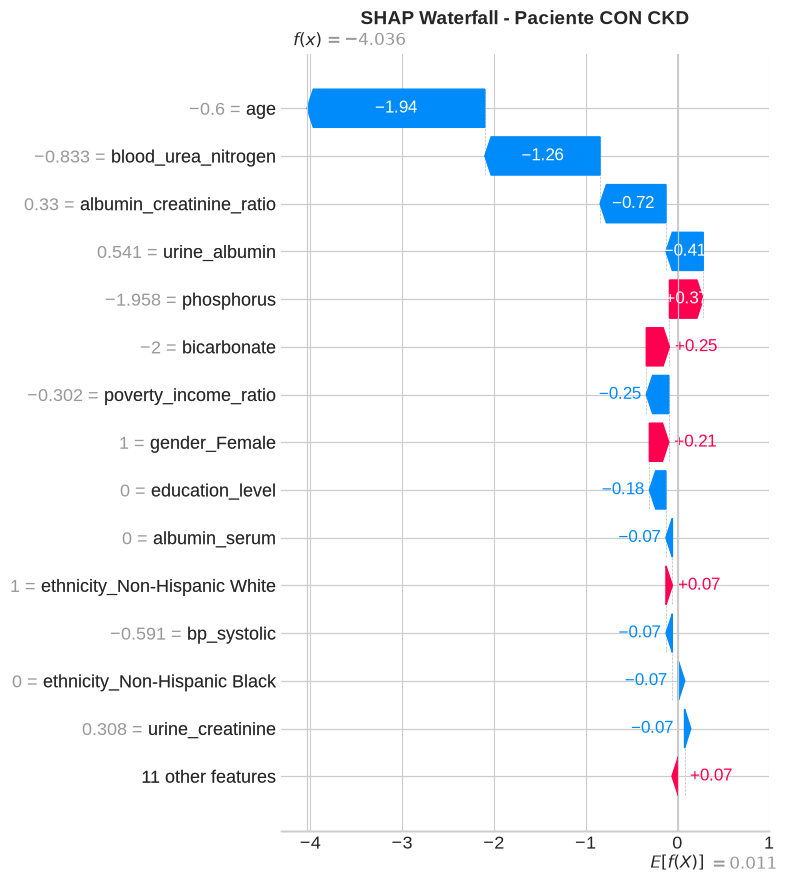

In [30]:
# Waterfall: paciente CON CKD
idx_ckd = np.where(y_test.values == 1)[0][0]
print(
    f"Paciente con CKD | Prob: {y_prob[idx_ckd]:.4f} | Real: CKD={y_test.iloc[idx_ckd]}"
)

expl_ckd = shap.Explanation(
    values=shap_vals[idx_ckd],
    base_values=base_val,
    data=X_test_prep[idx_ckd],
    feature_names=all_features,
)
plt.figure(figsize=(12, 8))
shap.plots.waterfall(expl_ckd, show=False, max_display=15)
plt.title("SHAP Waterfall - Paciente CON CKD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Paciente sin CKD | Prob: 0.0022 | Real: CKD=0


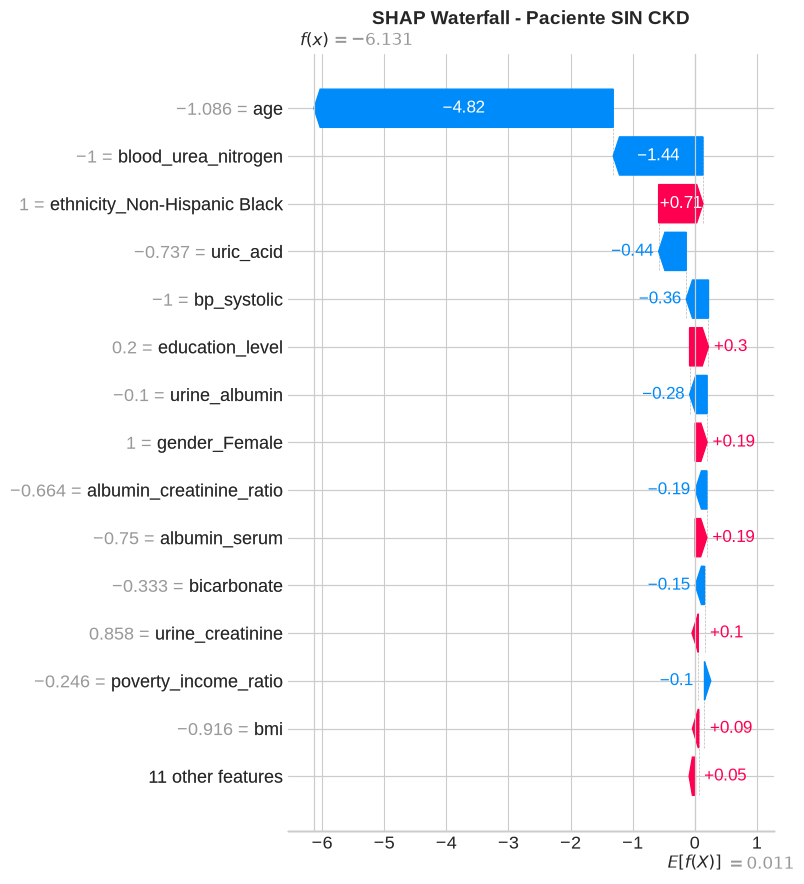

In [31]:
# Waterfall: paciente SIN CKD
idx_no = np.where(y_test.values == 0)[0][0]
print(
    f"Paciente sin CKD | Prob: {y_prob[idx_no]:.4f} | Real: CKD={y_test.iloc[idx_no]}"
)

expl_no = shap.Explanation(
    values=shap_vals[idx_no],
    base_values=base_val,
    data=X_test_prep[idx_no],
    feature_names=all_features,
)
plt.figure(figsize=(12, 8))
shap.plots.waterfall(expl_no, show=False, max_display=15)
plt.title("SHAP Waterfall - Paciente SIN CKD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## FASE 9: Redes Neuronales (TensorFlow/Keras)

Comparacion de dos arquitecturas de redes neuronales para clasificar ERC:

- **Somera**: 1 capa oculta (64 neuronas)
- **Profunda**: 4 capas ocultas (128-64-32-16)

Ambas se entrenan sobre los datos balanceados con SMOTE (`X_train_bal`), con 200 epochs, **EarlyStopping** y **decay exponencial** del learning rate. Metrica de evaluacion: **accuracy**.

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, optimizers
from tensorflow.keras.optimizers.schedules import ExponentialDecay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:", tf.__version__)
print("X_train_bal:", X_train_bal.shape, "| y_train_bal:", y_train_bal.shape)
print("X_test_prep:", X_test_prep.shape, "| y_test:", y_test.shape)

I0000 00:00:1786891277.183128   12317 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786891277.183502   12317 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786891277.574778   12317 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786891278.950805   12317 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow: 2.21.0


NameError: name 'X_train_bal' is not defined

In [4]:
# =====================================================================
# Configuracion compartida: EarlyStopping + decay exponencial
# =====================================================================
BATCH = 32
EPOCHS = 200
VAL_SPLIT = 0.2

decay_steps = int((len(X_train_bal) * (1 - VAL_SPLIT)) // BATCH)

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=decay_steps,
    decay_rate=0.9,
    staircase=True,
)

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

print(
    f"Decay steps/epoch: {decay_steps} | lr inicial: {lr_schedule.initial_learning_rate}"
)

NameError: name 'X_train_bal' is not defined

In [34]:
# =====================================================================
# ARQUITECTURA SOMERA: 1 capa oculta (64 neuronas)
# =====================================================================
shallow = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

shallow.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
shallow.summary()

hist_shallow = shallow.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1,
)

E0000 00:00:1786834521.216577  111332 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786834521.363646  111332 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,729 (6.75 KB)

...


  1/144 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9375 - loss: 0.3643


 83/144 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - accuracy: 0.8261 - loss: 0.3782


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.8285 - loss: 0.3723 - val_accuracy: 0.8129 - val_loss: 0.4081


Epoch 23: early stopping


Restoring model weights from the end of the best epoch: 8.


In [1]:
# =====================================================================
# ARQUITECTURA PROFUNDA: 4 capas ocultas (128-64-32-16)
# =====================================================================
deep = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

deep.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
deep.summary()

hist_deep = deep.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1,
)

NameError: name 'models' is not defined


===== Somera (1 capa) =====
Accuracy TEST: 0.8081
              precision    recall  f1-score   support

           0     0.8303    0.8315    0.8309       718
           1     0.7788    0.7774    0.7781       548

    accuracy                         0.8081      1266
   macro avg     0.8046    0.8044    0.8045      1266
weighted avg     0.8080    0.8081    0.8080      1266

Matriz de confusion:
[[597 121]
 [122 426]]



===== Profunda (4 capas) =====
Accuracy TEST: 0.8175
              precision    recall  f1-score   support

           0     0.8251    0.8607    0.8425       718
           1     0.8066    0.7609    0.7831       548

    accuracy                         0.8175      1266
   macro avg     0.8158    0.8108    0.8128      1266
weighted avg     0.8171    0.8175    0.8168      1266

Matriz de confusion:
[[618 100]
 [131 417]]


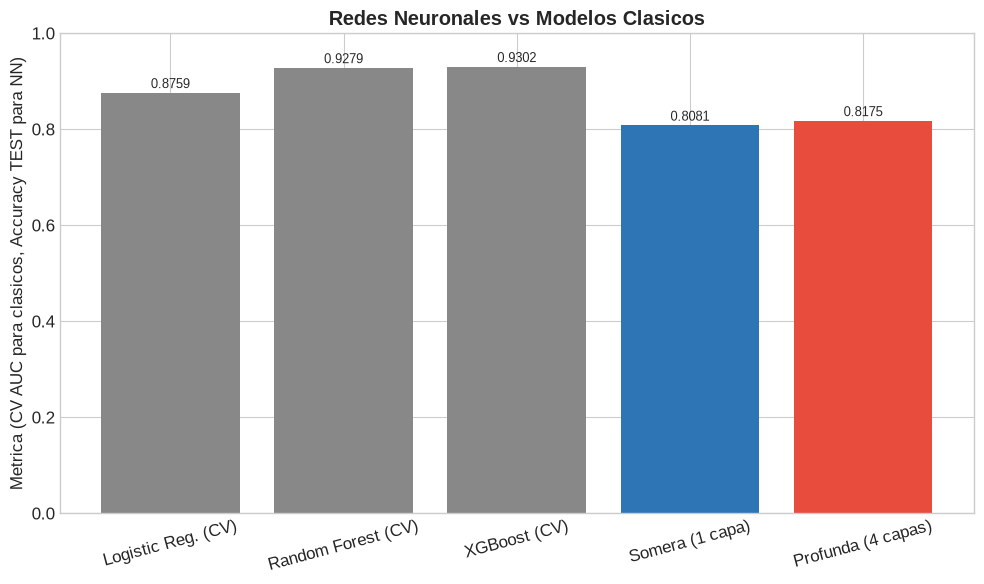


=== RESUMEN NN ===
  Somera (1 capa): accuracy test = 0.8081
  Profunda (4 capas): accuracy test = 0.8175


In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nombres = {"Somera (1 capa)": shallow, "Profunda (4 capas)": deep}
metricas = {}

for nombre, model in nombres.items():
    proba = model.predict(X_test_prep, verbose=0)
    y_pred = (proba >= 0.5).astype(int).ravel()
    acc_test = accuracy_score(y_test, y_pred)
    metricas[nombre] = acc_test
    print(f"\n===== {nombre} =====")
    print(f"Accuracy TEST: {acc_test:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))

# Comparacion con los modelos clasicos (CV sobre train balanceado)
comparacion = {
    "Logistic Reg. (CV)": float(results["Logistic Regression"]["AUC_mean"]),
    "Random Forest (CV)": float(results["Random Forest"]["AUC_mean"]),
    "XGBoost (CV)": float(results["XGBoost"]["AUC_mean"]),
}
comparacion.update(metricas)

plt.figure(figsize=(10, 6))
names = list(comparacion.keys())
vals = list(comparacion.values())
bars = plt.bar(names, vals, color=["#888"] * 3 + ["#2E75B6", "#E74C3C"])
plt.ylim(0, 1)
plt.ylabel("Metrica (CV AUC para clasicos, Accuracy TEST para NN)")
plt.title("Redes Neuronales vs Modelos Clasicos", fontweight="bold")
for bar, v in zip(bars, vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n=== RESUMEN NN ===")
for nombre, acc in metricas.items():
    print(f"  {nombre}: accuracy test = {acc:.4f}")

---
## FASE 10: Resumen

In [37]:
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(
    f"\nDataset: {df.shape[0]} registros -> {df_labs.shape[0]} con labs -> {len(all_features)} features"
)
print("Eliminadas por fuga: egfr, ckd_stage, serum_creatinine")
print("Preprocesamiento: KNNImputer + RobustScaler + log1p(ACR, urine_albumin)")
print("Balanceo: SMOTE")
print("Optimizacion: GridSearchCV")
print(f"\nMejor modelo: {best_name}")
print(f"AUC-ROC (test): {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR (test):  {average_precision_score(y_test, y_prob):.4f}")
print("\nTop 5 variables (SHAP):")
for _, row in shap_importance.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Mean |SHAP|']:.4f}")

RESUMEN FINAL

Dataset: 11933 registros -> 6326 con labs -> 25 features
Eliminadas por fuga: egfr, ckd_stage, serum_creatinine
Preprocesamiento: KNNImputer + RobustScaler + log1p(ACR, urine_albumin)
Balanceo: SMOTE
Optimizacion: GridSearchCV

Mejor modelo: XGBoost (optimizado)
AUC-ROC (test): 0.9061
AUC-PR (test):  0.8944

Top 5 variables (SHAP):
  - age: 1.9429
  - albumin_creatinine_ratio: 1.0745
  - blood_urea_nitrogen: 0.7439
  - uric_acid: 0.3948
  - urine_creatinine: 0.3187


### Limitaciones
- NHANES es transversal (no captura cronicidad de 3 meses KDIGO)
- ACR podria tener fuga parcial si definio ckd_present
- Poblacion estadounidense (requiere validacion externa)
- Se excluyeron eGFR y serum_creatinine para evitar circularidad

### Trabajo futuro
- Clasificacion multiclase (G1-G5)
- Sistema jerarquico binario + multiclase
- Validacion con cohortes externas
- Incorporar hemoglobina, cistatina C, HbA1c
- Modelos de progresion temporal
- Despliegue como herramienta clinica